# Inventory Forecasting - Feature Engineering

 ## Objectives
 1. Create meaningful features from raw data.
 2. Handle categorical variables.
 3. Generate time-series features.
 4. Prepare data for model training.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load and preprocess data
df = pd.read_excel('../data/Consumption Dataset.xlsx')
df['Date Time Served'] = pd.to_datetime(df['Date Time Served'])
df['Date'] = df['Date Time Served'].dt.date

# Remove negative values (data errors)
df = df[df['Consumed (ml)'] >= 0]
df = df[df['Purchase (ml)'] >= 0]

In [4]:
## remove negative aggregates
df = df[df['Consumed (ml)'] >= 0]
df[df['Opening Balance (ml)'] >= 0]

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Date
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2.555040e+03,1824.84,0.00,4379.88,2023-01-01
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1.344370e+03,0.00,0.00,1344.37,2023-01-01
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1.034280e+03,0.00,0.00,1034.28,2023-01-01
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2.194530e+03,0.00,0.00,2194.53,2023-01-01
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1.020900e+03,0.00,0.00,1020.90,2023-01-01
...,...,...,...,...,...,...,...,...,...
6570,2024-01-01 21:03:00,Anderson's Bar,Beer,Coors,2.467080e+03,0.00,321.06,2146.02,2024-01-01
6571,2024-01-01 21:15:00,Anderson's Bar,Rum,Malibu,8.526513e-14,1743.64,175.05,1568.59,2024-01-01
6572,2024-01-01 18:34:00,Anderson's Bar,Whiskey,Jack Daniels,4.192660e+03,0.00,197.60,3995.06,2024-01-01
6573,2024-01-01 22:46:00,Thomas's Bar,Vodka,Absolut,2.424950e+03,0.00,128.52,2296.43,2024-01-01


In [5]:
# Create daily aggregates
print("Creating daily aggregates...")
daily_data = df.groupby(['Date', 'Bar Name', 'Alcohol Type', 'Brand Name']).agg({
    'Consumed (ml)': 'sum',
    'Purchase (ml)': 'sum',
    'Opening Balance (ml)': 'last',
    'Closing Balance (ml)': 'last'
}).reset_index()

daily_data['Date'] = pd.to_datetime(daily_data['Date'])
daily_data = daily_data.sort_values(['Bar Name', 'Alcohol Type', 'Brand Name', 'Date'])

print(f"Daily aggregates created: {len(daily_data)} records")

Creating daily aggregates...
Daily aggregates created: 6575 records


In [6]:
# Create target variable (next day's consumption)
daily_data['Next_Day_Consumption'] = daily_data.groupby(
    ['Bar Name', 'Alcohol Type', 'Brand Name']
)['Consumed (ml)'].shift(-1)

# Remove rows without target (last day for each series)
daily_data = daily_data.dropna(subset=['Next_Day_Consumption'])
print(f"Records after creating target variable: {len(daily_data)}")

Records after creating target variable: 6479


 # Feature Engineering Steps


In [7]:
# time -based features
print("Creating time-based features...")
daily_data['DayOfWeek'] = daily_data['Date'].dt.dayofweek
daily_data['DayOfMonth'] = daily_data['Date'].dt.day
daily_data['Month'] = daily_data['Date'].dt.month
daily_data['WeekOfYear'] = daily_data['Date'].dt.isocalendar().week
daily_data['IsWeekend'] = (daily_data['DayOfWeek'] >= 5).astype(int)
daily_data['IsHolidaySeason'] = ((daily_data['Month'] == 12) | (daily_data['Month'] == 1)).astype(int)


Creating time-based features...


In [8]:
# 2. Lag features
print("Creating lag features...")
lags = [1, 2, 3, 7, 14]  # 1 day, 2 days, 3 days, 1 week, 2 weeks

for lag in lags:
    daily_data[f'Consumption_Lag_{lag}'] = daily_data.groupby(
        ['Bar Name', 'Alcohol Type', 'Brand Name']
    )['Consumed (ml)'].shift(lag)
    
    daily_data[f'Purchase_Lag_{lag}'] = daily_data.groupby(
        ['Bar Name', 'Alcohol Type', 'Brand Name']
    )['Purchase (ml)'].shift(lag)

Creating lag features...


In [9]:
# 3. Rolling statistics
print("Creating rolling features...")
windows = [3, 7, 14]  # 3 days, 1 week, 2 weeks

for window in windows:
    daily_data[f'Consumption_Mean_{window}'] = daily_data.groupby(
        ['Bar Name', 'Alcohol Type', 'Brand Name']
    )['Consumed (ml)'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    
    daily_data[f'Consumption_Std_{window}'] = daily_data.groupby(
        ['Bar Name', 'Alcohol Type', 'Brand Name']
    )['Consumed (ml)'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )
    
    daily_data[f'Consumption_Max_{window}'] = daily_data.groupby(
        ['Bar Name', 'Alcohol Type', 'Brand Name']
    )['Consumed (ml)'].transform(
        lambda x: x.rolling(window=window, min_periods=1).max()
    )

Creating rolling features...


In [10]:
# 4. Inventory-related features
print("Creating inventory features...")
daily_data['Inventory_Ratio'] = daily_data['Closing Balance (ml)'] / (daily_data['Consumed (ml)'] + 1)
daily_data['Stockout_Risk'] = (daily_data['Closing Balance (ml)'] / 
                              daily_data['Consumed (ml)'].rolling(7, min_periods=1).mean()).replace([np.inf, -np.inf], 0)
daily_data['Inventory_Turnover'] = daily_data['Consumed (ml)'] / (daily_data['Opening Balance (ml)'] + 1)
daily_data['Inventory_Usage_Rate'] = daily_data['Consumed (ml)'] / (daily_data['Opening Balance (ml)'] + 1)

Creating inventory features...


In [11]:
# 5. Categorical encoding
print("Creating categorical features...")
# Alcohol type dummies
alcohol_dummies = pd.get_dummies(daily_data['Alcohol Type'], prefix='Alcohol')
daily_data = pd.concat([daily_data, alcohol_dummies], axis=1)

# Bar location dummies  
bar_dummies = pd.get_dummies(daily_data['Bar Name'], prefix='Bar')
daily_data = pd.concat([daily_data, bar_dummies], axis=1)


Creating categorical features...


In [12]:
# 6. Product popularity features
print("Creating product popularity features...")
# Overall brand popularity
brand_popularity = daily_data.groupby('Brand Name')['Consumed (ml)'].mean().to_dict()
daily_data['Brand_Popularity'] = daily_data['Brand Name'].map(brand_popularity)

# Bar-specific brand popularity
bar_brand_popularity = daily_data.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)'].mean().reset_index()
bar_brand_popularity_dict = bar_brand_popularity.set_index(['Bar Name', 'Brand Name'])['Consumed (ml)'].to_dict()
daily_data['Bar_Brand_Popularity'] = daily_data.set_index(['Bar Name', 'Brand Name']).index.map(
    lambda x: bar_brand_popularity_dict.get(x, 0)
).values

Creating product popularity features...


In [13]:
# 7. Trend features
print("Creating trend features...")
daily_data['Consumption_Trend_7d'] = daily_data.groupby(
    ['Bar Name', 'Alcohol Type', 'Brand Name']
)['Consumed (ml)'].transform(
    lambda x: x.rolling(window=7, min_periods=1).apply(
        lambda y: np.polyfit(range(len(y)), y, 1)[0] if len(y) > 1 else 0
    )
)

Creating trend features...


In [15]:
# Handle missing values from lag/rolling features
print("Handling missing values...")
numeric_columns = daily_data.select_dtypes(include=[np.number]).columns
daily_data[numeric_columns] = daily_data[numeric_columns].fillna(0)

print(f"Final dataset shape: {daily_data.shape}")

# %%
# Feature analysis
feature_columns = [col for col in daily_data.columns if col not in [
    'Date', 'Bar Name', 'Alcohol Type', 'Brand Name', 
    'Next_Day_Consumption', 'Consumed (ml)', 'Purchase (ml)',
    'Opening Balance (ml)', 'Closing Balance (ml)'
]]


print(f"Total features created: {len(feature_columns)}")
print("\nFeature categories:")
print(f"- Time features: {len([f for f in feature_columns if f.startswith(('Day', 'Month', 'Week', 'Is'))])}")
print(f"- Lag features: {len([f for f in feature_columns if 'Lag' in f])}")
print(f"- Rolling features: {len([f for f in feature_columns if 'Mean' in f or 'Std' in f or 'Max' in f])}")
print(f"- Inventory features: {len([f for f in feature_columns if 'Inventory' in f or 'Stockout' in f])}")
print(f"- Categorical encodings: {len([f for f in feature_columns if f.startswith(('Alcohol_', 'Bar_'))])}")
print(f"- Popularity features: {len([f for f in feature_columns if 'Popularity' in f])}")
print(f"- Trend features: {len([f for f in feature_columns if 'Trend' in f])}")

Handling missing values...
Final dataset shape: (6479, 52)
Total features created: 43

Feature categories:
- Time features: 6
- Lag features: 10
- Rolling features: 9
- Inventory features: 4
- Categorical encodings: 12
- Popularity features: 2
- Trend features: 1


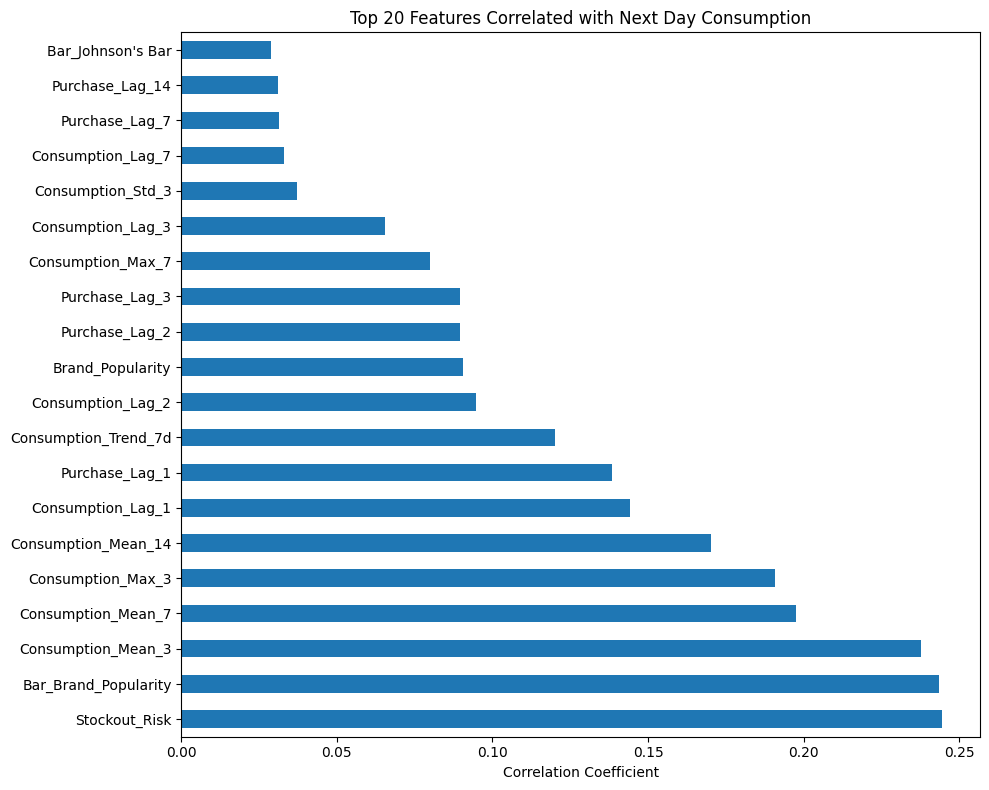

In [16]:
# Correlation with target
correlation_with_target = daily_data[feature_columns + ['Next_Day_Consumption']].corr()['Next_Day_Consumption'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlation_with_target[1:21].plot(kind='barh')  # Top 20 features excluding target itself
plt.title('Top 20 Features Correlated with Next Day Consumption')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [17]:
# Feature importance preview (using correlation)
top_features = correlation_with_target[1:11]  # Top 10 features
print("Top 10 features by correlation with target:")
for feature, corr in top_features.items():
    print(f"{feature}: {corr:.3f}")

Top 10 features by correlation with target:
Stockout_Risk: 0.244
Bar_Brand_Popularity: 0.244
Consumption_Mean_3: 0.238
Consumption_Mean_7: 0.197
Consumption_Max_3: 0.191
Consumption_Mean_14: 0.170
Consumption_Lag_1: 0.144
Purchase_Lag_1: 0.139
Consumption_Trend_7d: 0.120
Consumption_Lag_2: 0.095


In [18]:
# Save engineered features
daily_data.to_csv('../data/engineered_features.csv', index=False)
print("Engineered features saved to '../data/engineered_features.csv'")

Engineered features saved to '../data/engineered_features.csv'


In [19]:
# Prepare for modeling
X = daily_data[feature_columns]
y = daily_data['Next_Day_Consumption']

print(f"Final feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

Final feature matrix shape: (6479, 43)
Target variable shape: (6479,)


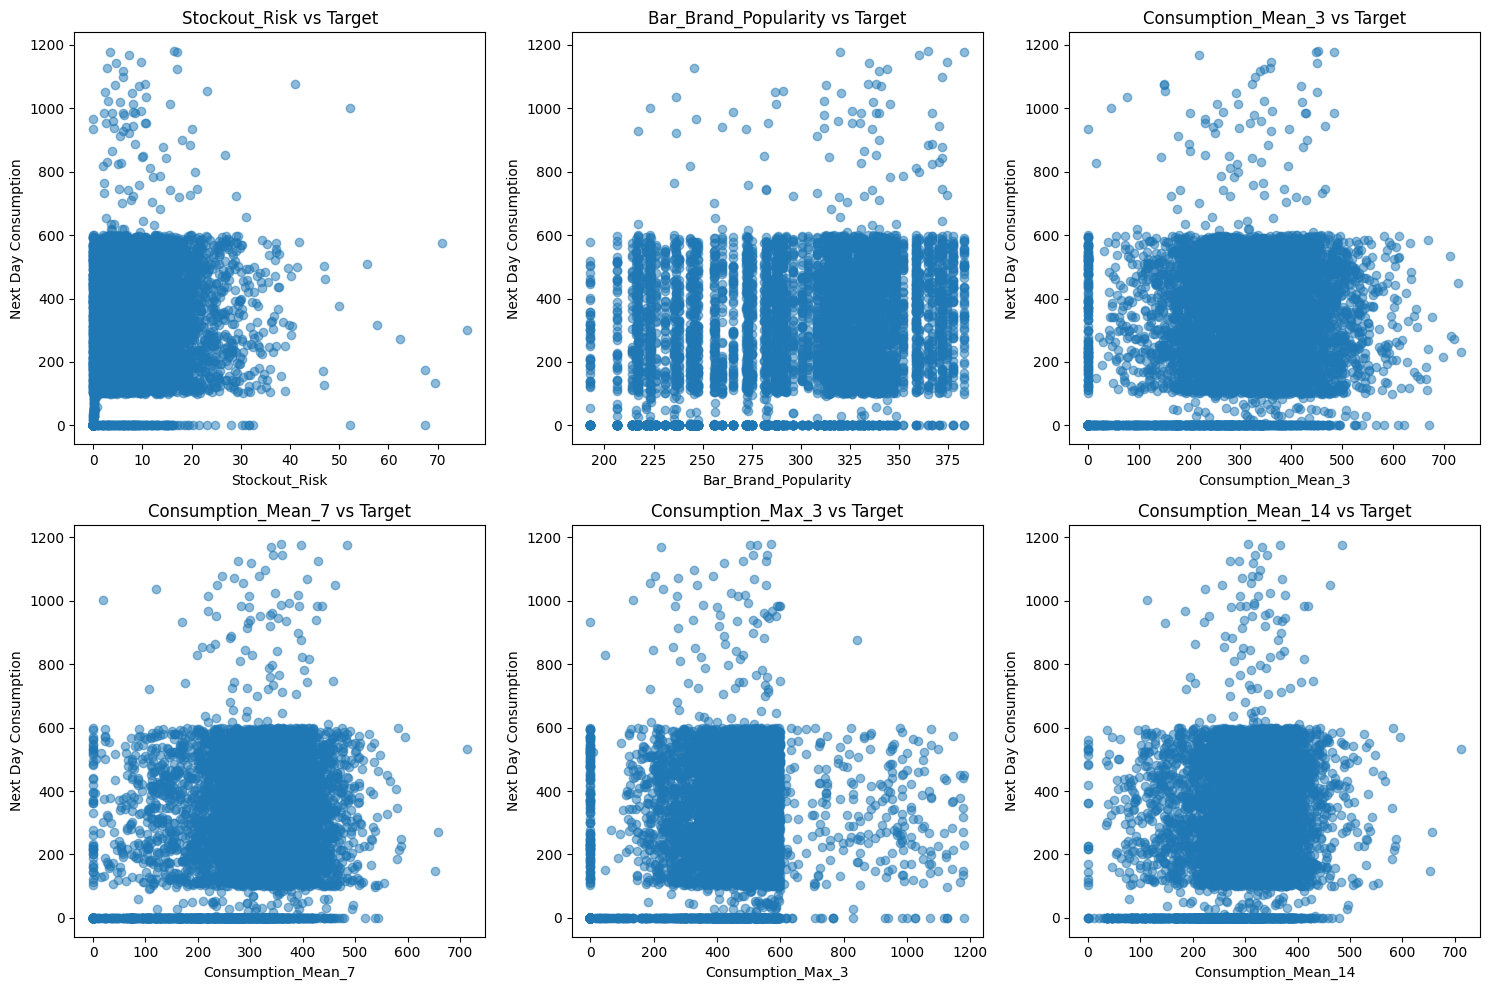

In [20]:
# Feature distributions
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features.index[:6]):
    plt.subplot(2, 3, i+1)
    plt.scatter(daily_data[feature], daily_data['Next_Day_Consumption'], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Next Day Consumption')
    plt.title(f'{feature} vs Target')
plt.tight_layout()
plt.show()

In [21]:
print("=== FEATURE ENGINEERING COMPLETED ===")
print(f"Original features: 8")
print(f"Engineered features: {len(feature_columns)}")
print(f"Total features: {len(feature_columns)}")
print(f"Training samples: {len(X)}")
print("\nReady for model training!")

=== FEATURE ENGINEERING COMPLETED ===
Original features: 8
Engineered features: 43
Total features: 43
Training samples: 6479

Ready for model training!
